# **Trabalho: Métodos de Previsão Aplicados**

#**2. Análise Exploratória de Dados**
## **2.1. Extração de dados**

### **Bibliotecas**

In [ ]:
# @title
import requests
import json
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime
#Modelo Multiplicativo e Aditivo e ACF e PACF e  Média Móvel
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sm_tsaplots
import matplotlib.pyplot as plt
# Analise da dependencia temporal
import seaborn as sns
#Feriados
import holidays



### **Função extração**

In [ ]:
# @title
def extract_data_atendimentos_nos_csp_gripe(ars, start_date, end_date, cols=['no_consultas_gripe_nos_csp']):
    """
    Extracts daily data from the dataset 'Atendimentos nos CSP - Gripe'
    available at the SNS Transparency Portal.

    Parameters
    ----------
    ars : str
        Health region name used in the dataset (e.g., 'Norte', 'Centro',
        'Lisboa e Vale do Tejo', 'Alentejo', 'Algarve').
    start_date : str (YYYY-MM-DD)
        Start date of the extraction interval (inclusive).
    end_date : str (YYYY-MM-DD)
        End date of the extraction interval (inclusive).
    cols : list of str, optional
        Names of the variables to retain in the returned DataFrame.
        By default, keeps the influenza-related consultation count.

    Returns
    -------
    pandas.DataFrame
        A tidy DataFrame indexed by date, filtered by region and time
        interval, containing the selected variables.
    """
    indicator = "atendimentos-nos-csp-gripe"
    base_url = f"https://transparencia.sns.gov.pt/api/explore/v2.1/catalog/datasets/{indicator}/records"

    limit = 100
    df_data = pd.DataFrame()

    date_ranges = pd.date_range(start=start_date, end=end_date, freq=f"{limit}D", inclusive="left")

    for i, s_date in enumerate(date_ranges):
        s_date = s_date.strftime("%Y-%m-%d")
        e_date = (date_ranges[i + 1] - pd.Timedelta("1D")).strftime("%Y-%m-%d") if i < len(date_ranges) - 1 else end_date

        params = {
            "where": f'regiao="{ars}" AND dia>=date\'{s_date}\' AND dia<=date\'{e_date}\'',
            "limit": limit
        }

        response = requests.get(base_url, params=params)
        response.raise_for_status()

        data_extract = response.json()
        df_aux = pd.json_normalize(data_extract.get("results", []))

        if not df_aux.empty:
            df_data = pd.concat([df_data, df_aux], ignore_index=True)

    if not df_data.empty:
        df_data["dia"] = pd.to_datetime(df_data["dia"], errors="coerce")
        for c in cols:
            if c in df_data.columns:
                df_data[c] = pd.to_numeric(df_data[c], errors="coerce")
        df_data = df_data.dropna(subset=["dia"]).sort_values("dia").reset_index(drop=True)
        df_data = df_data.filter(["dia"] + cols)

    return df_data

### **Executar a extração para o Centro**



---



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   dia                         215 non-null    datetime64[ns]
 1   no_consultas_gripe_nos_csp  215 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


None

,dia,no_consultas_gripe_nos_csp
210,2026-01-27,112.0
211,2026-01-28,58.0
212,2026-01-29,65.0
213,2026-01-30,63.0
214,2026-01-31,10.0


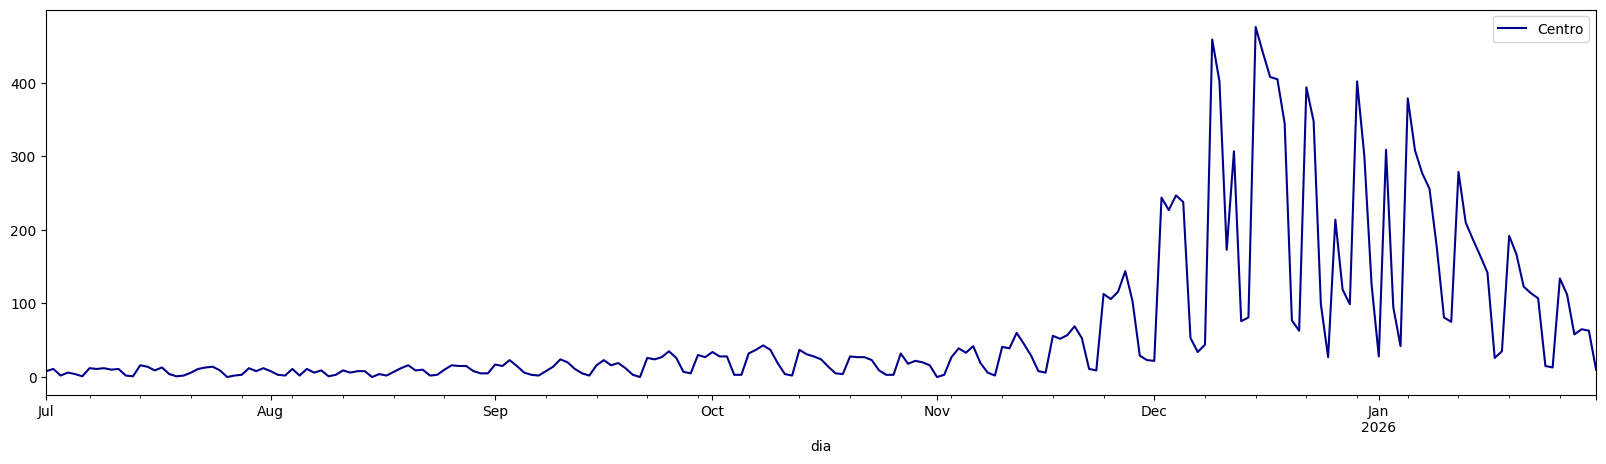

In [ ]:
df_centro = extract_data_atendimentos_nos_csp_gripe(
    ars="Centro",
    start_date="2025-07-01",
    end_date="2026-01-31" #aqui é suposto ser ate que dia?? porque se for fev ou março depois nao da para prever as semanas que se pede ou dá?
)
display(df_centro.info())
display(df_centro.tail())
df_centro.plot(x="dia", y="no_consultas_gripe_nos_csp", figsize=(20,5), label="Centro", color="darkblue");

### **Estatísticas Descritivas**

In [ ]:
# Estatística descritiva básica
print("Resumo Estatístico das Consultas:")
display(df_centro['no_consultas_gripe_nos_csp'].describe())

print()
# Verificar a amplitude (Máximo - Mínimo)
amplitude = df_centro['no_consultas_gripe_nos_csp'].max() - df_centro['no_consultas_gripe_nos_csp'].min()
print(f"Amplitude da série: {amplitude}")

Resumo Estatístico das Consultas:


,no_consultas_gripe_nos_csp
count,215.000000
mean,65.595349
std,104.645235
min,0.000000
25%,8.000000
50%,20.000000
75%,63.000000
max,476.000000



Amplitude da série: 476.0


In [ ]:
Y_df = (
    df_centro
    .assign(unique_id='Centro')
    .reset_index()
    #.rename(columns={'index': 'ds'})
    .rename(columns={'Centro': 'no_consultas_gripe_nos_csp'})
    .filter(['unique_id', 'dia', 'no_consultas_gripe_nos_csp'])
    )
display(Y_df.info())
display(Y_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   unique_id                   215 non-null    object        
 1   dia                         215 non-null    datetime64[ns]
 2   no_consultas_gripe_nos_csp  215 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 5.2+ KB


None

,unique_id,dia,no_consultas_gripe_nos_csp
0,Centro,2025-07-01,8.0
1,Centro,2025-07-02,11.0
2,Centro,2025-07-03,2.0
3,Centro,2025-07-04,6.0
4,Centro,2025-07-05,4.0
...,...,...,...
210,Centro,2026-01-27,112.0
211,Centro,2026-01-28,58.0
212,Centro,2026-01-29,65.0
213,Centro,2026-01-30,63.0


### 2.2. Tratamento e Limpeza
#### 2.2.1. Formatação do Índice Temporal e Frequência

In [ ]:
#Conversão para datetime, periodicidade diária e índice
df_centro_ts = (df_centro
    .assign(dia = lambda x: pd.to_datetime(x.dia).dt.to_period("D")) # 1º e 2º passo: datetime e periodicidade 'D' (diária)
    .set_index("dia")                                               # 3º passo: definir como índice
    .sort_index()                                                   # Extra: garantir que as datas estão por ordem
)

# Aplicar o asfreq('D') para garantir que não faltam dias (como ensinado no NB1)
df_centro = df_centro_ts.asfreq('D')

display(df_centro.info(), df_centro_ts.head(3), df_centro_ts.tail(3))

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 215 entries, 2025-07-01 to 2026-01-31
Freq: D
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   no_consultas_gripe_nos_csp  215 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


None

,no_consultas_gripe_nos_csp
dia,
2025-07-01,8.0
2025-07-02,11.0
2025-07-03,2.0


,no_consultas_gripe_nos_csp
dia,
2026-01-29,65.0
2026-01-30,63.0
2026-01-31,10.0


In [ ]:
#Validação e Formatação do Índice Temporal
print("df_centro freq: ", df_centro.index.freq)

try:
    print(df_centro.index.inferred_freq)
except Exception:
    print("df_centro inferred_freq: Erro")

df_centro freq:  <Day>
df_centro inferred_freq: Erro


#### 2.2.2.Verificar e Tratamento de Valores em Falta

In [ ]:
#total de valores em falta
print(f"Valores nulos: {df_centro['no_consultas_gripe_nos_csp'].isna().sum()}")

#verificar zeros (para evitar erros na decomposição multiplicativa)
print(f"Dias com zero consultas: {(df_centro['no_consultas_gripe_nos_csp'] == 0).sum()}")

Valores nulos: 0
Dias com zero consultas: 4


### 2.2.3. Média Móvel: Suavização da Série Temporal (Tendência)

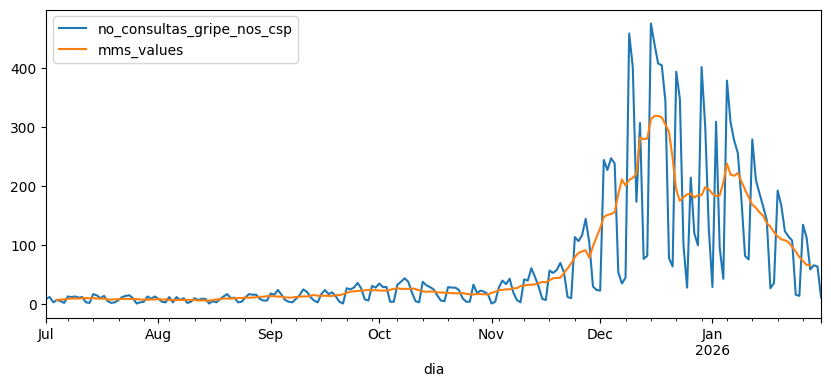

In [ ]:
#calcular média móvel de 7 dias para visualização (suavizar a componente sazonal)
df_centro_mms = df_centro.copy()
df_centro_mms["mms_values"] = df_centro_mms['no_consultas_gripe_nos_csp'].rolling(window=7, center=True).mean()
df_centro_mms.index = df_centro_mms.index.to_timestamp()

# 4. O gráfico final
df_centro_mms.plot(figsize=(10,4));

####2.2.4. Preparação do Calendário Português

In [ ]:
# 1. Criar calendário de feriados oficiais
pt_holidays = holidays.Portugal(years=[2023, 2024, 2025, 2026])

# 2. Lista manual (Greves e Tolerâncias)
datas_extra = [
    '2023-07-05', '2023-07-06', '2023-07-25', '2023-07-26', '2023-07-27',
    '2023-08-09', '2023-08-10', '2023-12-26', '2024-01-02', '2024-07-23',
    '2024-07-24', '2024-09-24', '2024-09-25', '2024-12-24', '2024-12-31',
    '2025-10-23', '2025-12-10', '2025-12-24', '2025-12-26', '2025-12-31',
    '2026-02-17'
]
datas_extra_dt = pd.to_datetime(datas_extra).date

# 3. Função de verificação
def verifica_nao_util(data):
    # data aqui será um Timestamp do pandas vindo do índice
    if data.weekday() >= 5:
        return 1  # Fim de semana
    if data in pt_holidays:
        return 1  # Feriado oficial
    if data.date() in datas_extra_dt:
        return 1  # Greve ou Tolerância
    return 0

# 4. Aplicar ao DataFrame
# Criamos a coluna 'nao_util' que resume tudo (feriados, fds, greves)
df_centro['nao_util'] = df_centro.index.to_timestamp().map(verifica_nao_util)

# 5. Adicionar também o dia_semana (útil para o modelo aprender o padrão de cada dia)
df_centro['dia_semana'] = df_centro.index.to_timestamp().weekday

print("Engenharia de Atributos completa (Feriados, Greves e Fim de Semana):")
display(df_centro.query("nao_util == 1").tail(10))

Engenharia de Atributos completa (Feriados, Greves e Fim de Semana):


,no_consultas_gripe_nos_csp,nao_util,dia_semana
dia,,,
2026-01-01,28.0,1,3
2026-01-03,95.0,1,5
2026-01-04,42.0,1,6
2026-01-10,81.0,1,5
2026-01-11,75.0,1,6
2026-01-17,26.0,1,5
2026-01-18,35.0,1,6
2026-01-24,15.0,1,5
2026-01-25,13.0,1,6


### 2.3.Análise de Dependência Temporal

/tmp/ipykernel_11030/2144733465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sazonal, x='dia_semana_num', y='no_consultas_gripe_nos_csp', palette='coolwarm')


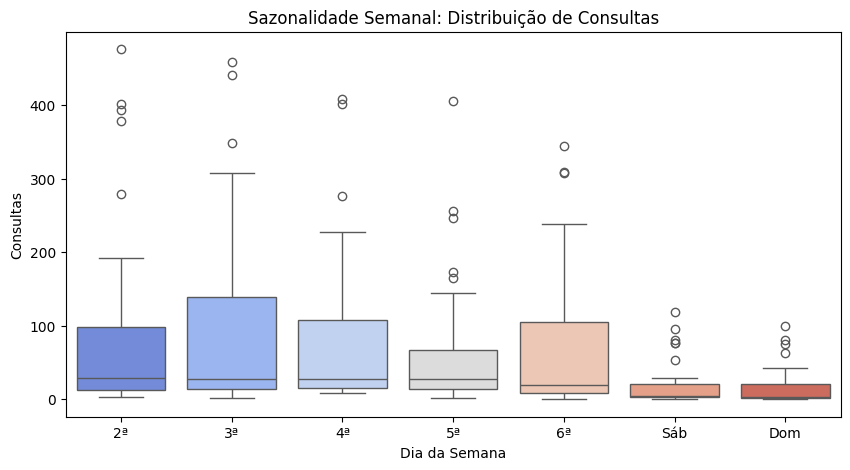

In [ ]:
df_sazonal = df_centro.copy()
df_sazonal.index = df_sazonal.index.to_timestamp() # Única linha de ajuste técnico
df_sazonal = df_sazonal.reset_index()

# 2. Criar a coluna do dia da semana
# O nome da coluna de data no teu caso é 'dia'
df_sazonal['dia_semana_num'] = df_sazonal['dia'].dt.dayofweek

# 3. Gráfico de Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_sazonal, x='dia_semana_num', y='no_consultas_gripe_nos_csp', palette='coolwarm')

# 4. Legendas
plt.xticks(ticks=range(7), labels=['2ª', '3ª', '4ª', '5ª', '6ª', 'Sáb', 'Dom'])
plt.title('Sazonalidade Semanal: Distribuição de Consultas')
plt.ylabel('Consultas')
plt.xlabel('Dia da Semana')
plt.show()

#### 2.3.1. Correlograma (ACF)

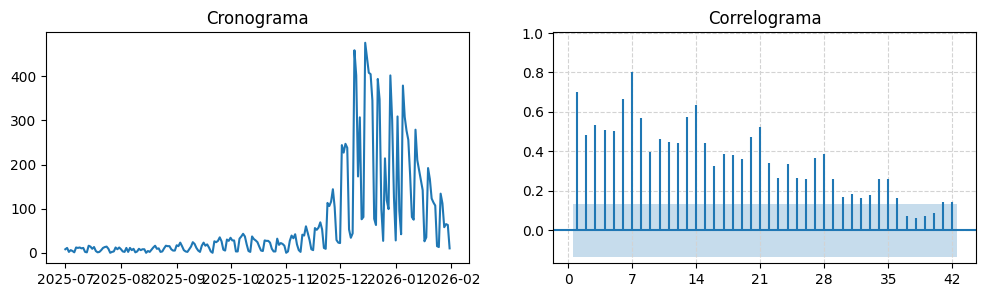

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,3))

# 1.
ax[0].plot(df_centro.index.to_timestamp(), df_centro['no_consultas_gripe_nos_csp'])
ax[0].set_title("Cronograma")

# 2.
sm_tsaplots.plot_acf(df_centro['no_consultas_gripe_nos_csp'].dropna(), lags=42, bartlett_confint=False, zero=False, marker='', auto_ylims=True, ax=ax[1])
ax[1].set_title("Correlograma")
ax[1].grid(which='major', color='lightgrey', linestyle="--")

# 3
ax[1].set_xticks(range(0, 43, 7))

plt.show()

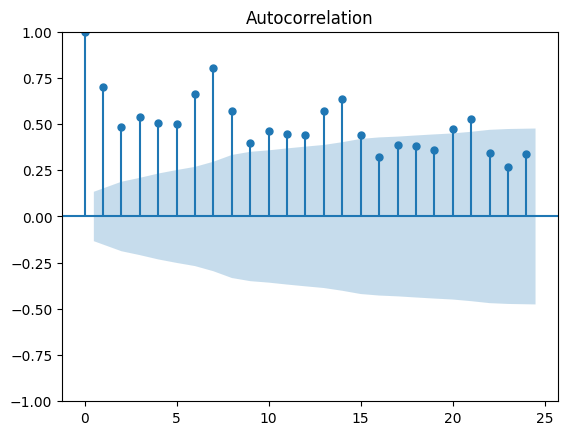

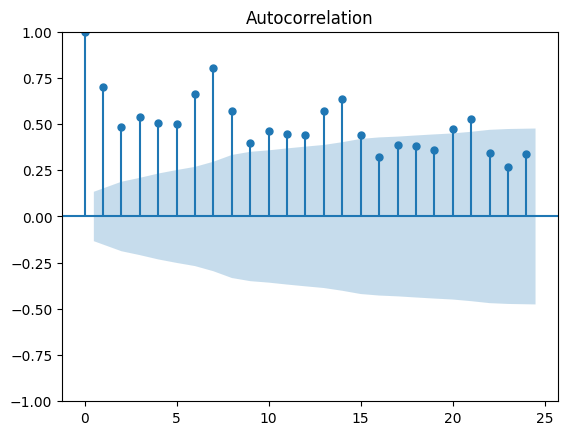

In [ ]:
sm_tsaplots.plot_acf(df_centro['no_consultas_gripe_nos_csp'])

#### 2.3.2.Autocorrelação Parcial (PACF)

In [ ]:
import statsmodels.api as sm
# valor das autocorrelações da ordem 0 até à ordem 8
sm.tsa.acf(df_centro['no_consultas_gripe_nos_csp'], nlags=8)

array([1.        , 0.69920335, 0.48407302, 0.53620811, 0.50588694,
       0.50103437, 0.66348812, 0.80290624, 0.57078436])

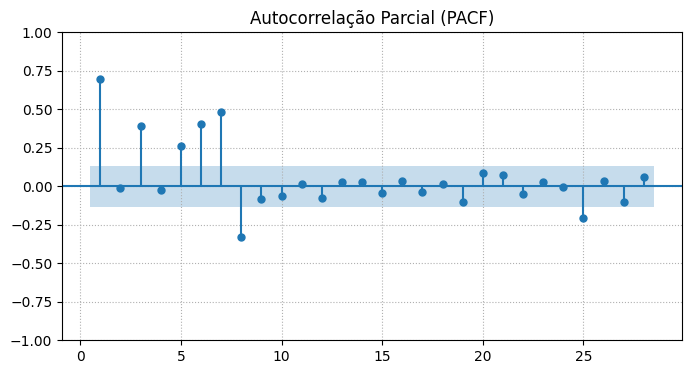

In [ ]:
#criar o gráfico de autocorrelação parcial (pacf)
fig, ax = plt.subplots(figsize=(8, 4))
sm_tsaplots.plot_pacf(df_centro['no_consultas_gripe_nos_csp'],
                      lags=28,
                      zero=False,
                      ax=ax)
ax.set_title('Autocorrelação Parcial (PACF)')
ax.grid(which='major', linestyle=':')
plt.show()

### 2.3.3. Decomposição Sazonal

**Modelo aditivo**

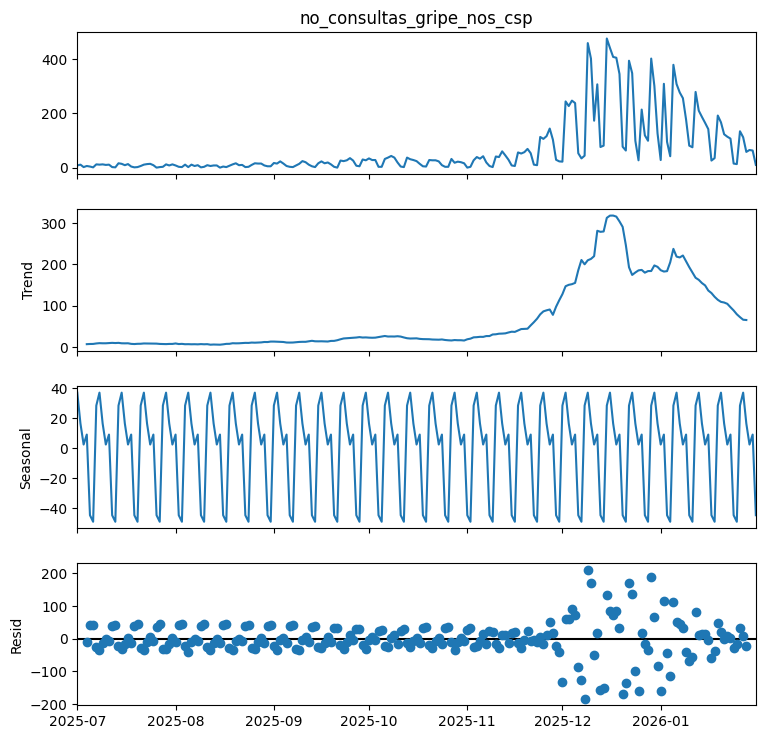

In [ ]:
# 1. Preparar os dados
# Criamos uma cópia e convertemos o índice para timestamp apenas para o gráfico
df_input = df_centro['no_consultas_gripe_nos_csp'].copy()
df_input.index = df_input.index.to_timestamp()

# 2.
decomp_clas_ad = seasonal_decompose(df_input, model="additive", period=7)
fig = decomp_clas_ad.plot()
fig.set_size_inches((8,8));

In [ ]:
df_decomp = pd.DataFrame({
    "observed": decomp_clas_ad.observed,
    "trend": decomp_clas_ad.trend,
    "seasonal": decomp_clas_ad.seasonal,
    "residual": decomp_clas_ad.resid
})

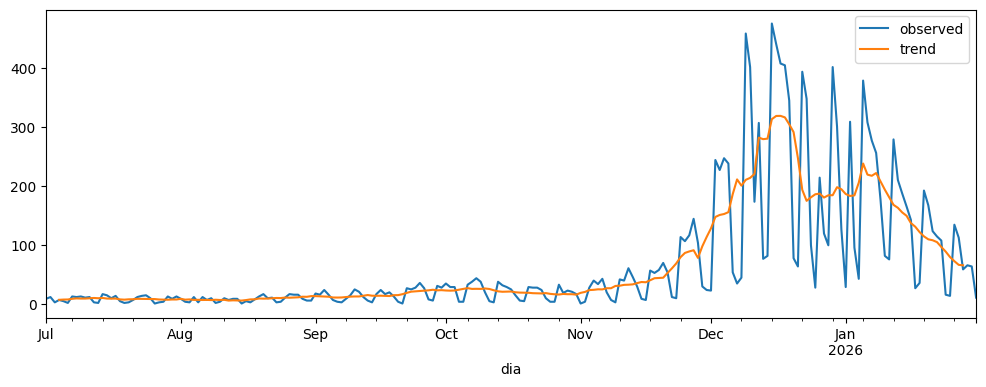

In [ ]:
# 2. O
df_decomp.filter(["observed","trend"]).plot(figsize=(12,4));

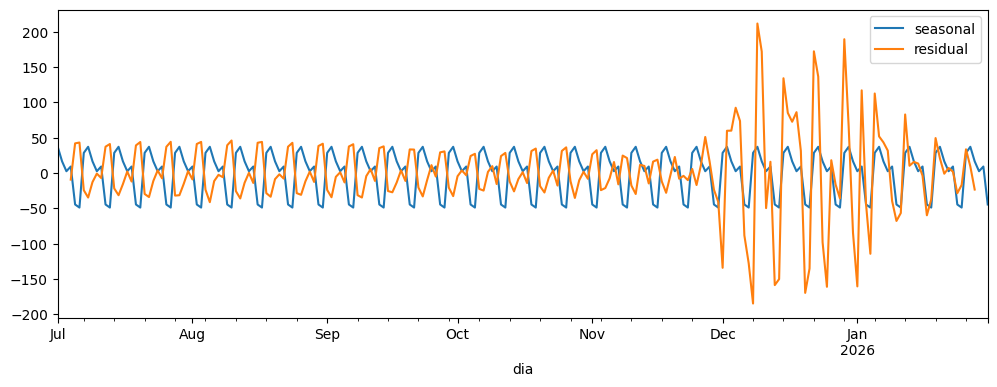

In [ ]:
# Customizar a visualização, agora apenas com a componente sazonal e com a componente irregular
df_decomp.filter(["seasonal","residual"]).plot(figsize=(12,4));

**Modelo Multiplicativo**

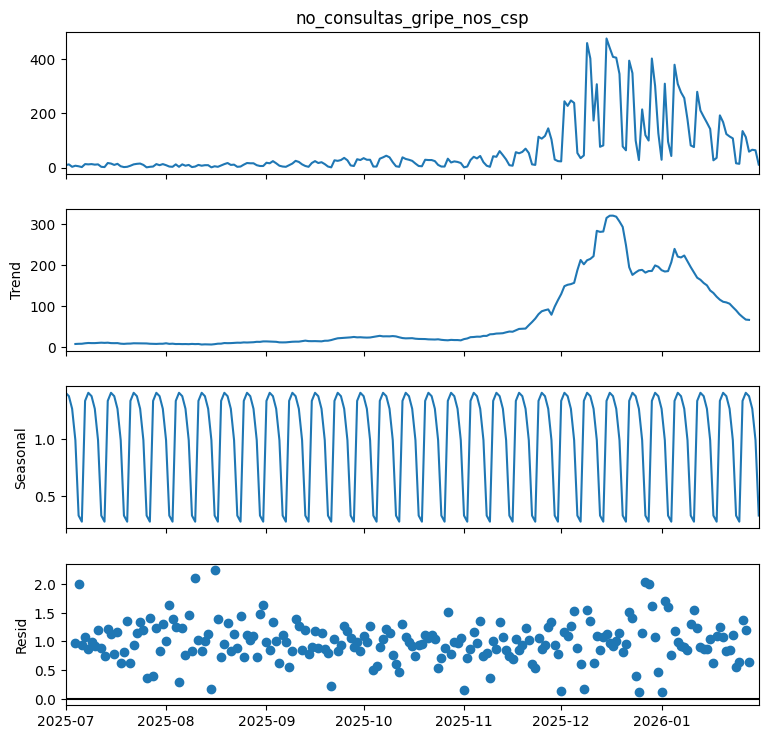

In [ ]:
# 1. Preparar os dados
# Criamos uma cópia e convertemos o índice para timestamp apenas para o gráfico
df_input = df_centro['no_consultas_gripe_nos_csp'].copy() +1
df_input.index = df_input.index.to_timestamp()

# 2.
decomp_clas_mult = seasonal_decompose(df_input, model="multiplicative", period=7)
fig = decomp_clas_mult.plot()
fig.set_size_inches((8,8));

<Axes: xlabel='dia'>

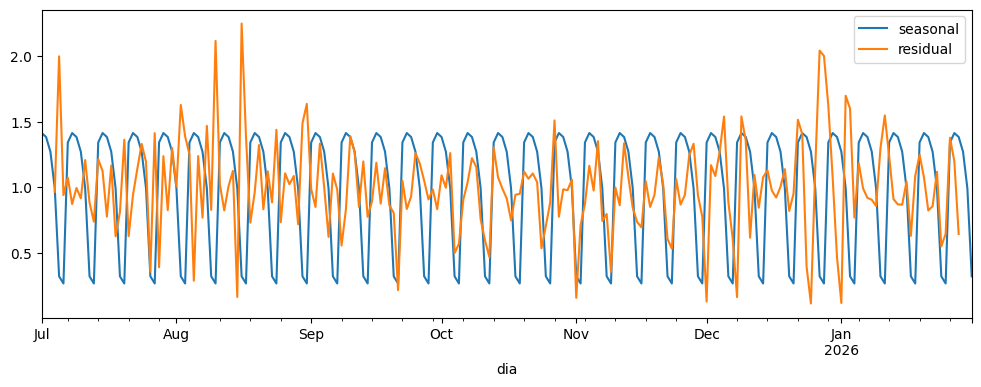

In [ ]:
df_decomp_clas_mult = pd.DataFrame({"observed": decomp_clas_mult.observed,
                                    "trend": decomp_clas_mult.trend,
                                    "seasonal": decomp_clas_mult.seasonal,
                                    "residual": decomp_clas_mult.resid})
# Obter visualização mais útil para comparar as duas decomposições clássicas
df_decomp_clas_mult.filter(["seasonal","residual"]).plot(figsize=(12,4))

In [ ]:
# 1. Resetar o índice para o 'dia' voltar a ser uma coluna
gafa = df_centro.reset_index()

# 2. Converter o 'dia' (que estava como Period) para Timestamp (Data normal)
# Usamos o .dt para aceder às propriedades de data
gafa['dia'] = gafa['dia'].dt.to_timestamp()

# 3. Calcular a diferença diária (Diferenciação de 1ª ordem)
goog_return = gafa.assign(daily_diff=gafa['no_consultas_gripe_nos_csp'].diff(1))

# 4. Mostrar o resultado
display(goog_return.info(), goog_return.head())

from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Aplicar o teste de Ljung-Box sobre a série diferenciada (sem a tendência)
# Usamos .dropna() porque o primeiro valor da daily_diff é NaN e o teste daria erro
resultado_lb = acorr_ljungbox(goog_return['daily_diff'].dropna(), lags=[10], return_df=True)

# 2. Mostrar o resultado (o que importa é o lb_pvalue)
display(resultado_lb)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   dia                         215 non-null    datetime64[ns]
 1   no_consultas_gripe_nos_csp  215 non-null    float64       
 2   nao_util                    215 non-null    int64         
 3   dia_semana                  215 non-null    int32         
 4   daily_diff                  214 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1)
memory usage: 7.7 KB


None

,dia,no_consultas_gripe_nos_csp,nao_util,dia_semana,daily_diff
0,2025-07-01,8.0,0,1,NaN
1,2025-07-02,11.0,0,2,3.0
2,2025-07-03,2.0,0,3,-9.0
3,2025-07-04,6.0,0,4,4.0
4,2025-07-05,4.0,1,5,-2.0


,lb_stat,lb_pvalue
10,197.880802,4.464238e-37


In [ ]:
# aplicação o teste de Ljung-Box até à ordem recomendada
sm.stats.acorr_ljungbox(goog_return.daily_diff.dropna(), lags=10)

,lb_stat,lb_pvalue
1,4.303870,3.802576e-02
2,47.788285,4.196679e-11
3,51.934647,3.092691e-11
4,52.295193,1.196671e-10
5,69.465177,1.324084e-13
6,69.723951,4.658138e-13
7,155.687212,2.590735e-30
8,157.581360,5.123350e-30
9,193.913267,6.243718e-37
10,197.880802,4.464238e-37
